# Task 06 — Classification Algorithms Comparison

## 1. Dataset Setup and Loading

This project focuses on predicting whether a customer will subscribe to a bank term deposit as a result of a marketing campaign.

The analysis compares multiple classification algorithms and evaluates them using metrics that are appropriate for an imbalanced classification problem.

The Bank Marketing dataset from the UCI Machine Learning Repository is used for this task.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

# Load the original CSV from the ZIP file
zip_path = "bank-additional-full.csv.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    with z.open("bank-additional-full.csv") as f:
        df = pd.read_csv(f, sep=";")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (41188, 21)

First 5 rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no



Column names:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


## 2. Initial Dataset Inspection

The dataset contains demographic, financial, contact, and campaign-related features.

Before modelling, the data is inspected for data types, missing values, duplicate records, and the distribution of the target variable.

In [2]:
print("Data types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(df["y"].value_counts())

print("\nTarget percentage:")
display((df["y"].value_counts(normalize=True) * 100).round(2))

Data types:


,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object



Missing values:


,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0



Duplicate rows: 12

Target distribution:


,count
y,
no,36548
yes,4640



Target percentage:


,proportion
y,
no,88.73
yes,11.27


## 3. Data Cleaning

The dataset contains categorical variables with `unknown` values. These values are treated as a separate category rather than being automatically removed because an `unknown` response may itself contain useful information about the customer.

Duplicate observations are also checked before modelling.

In [3]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

# Check 'unknown' values in categorical columns
categorical_columns = df.select_dtypes(include="object").columns

unknown_counts = {}

for col in categorical_columns:
    unknown_counts[col] = (df[col] == "unknown").sum()

unknown_counts = pd.Series(unknown_counts).sort_values(ascending=False)

print("\nUnknown values by categorical column:")
display(unknown_counts)

Duplicate rows: 12

Unknown values by categorical column:


,0
default,8597
education,1731
housing,990
loan,990
job,330
marital,80
contact,0
month,0
day_of_week,0
poutcome,0


## 4. Removing Duplicate Observations

Twelve duplicate observations were identified in the dataset. Since duplicate records can give repeated observations disproportionate influence during model training, they are removed before further analysis.

Unknown categorical responses are retained because removing these observations would unnecessarily reduce the dataset and could introduce selection bias.

In [4]:
# Remove duplicate rows
before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

after = len(df)

print("Rows before removing duplicates:", before)
print("Duplicate rows removed:", before - after)
print("Rows after removing duplicates:", after)

Rows before removing duplicates: 41188
Duplicate rows removed: 12
Rows after removing duplicates: 41176


## 5. Target Variable Preparation

The target variable `y` indicates whether the client subscribed to a term deposit.

For binary classification, the target is encoded as:

- `no` → 0
- `yes` → 1

The original categorical features are retained in their original form at this stage and will be encoded as part of the modelling pipeline.

In [5]:
# Encode target variable
df["y"] = df["y"].map({"no": 0, "yes": 1})

print("Target distribution:")
print(df["y"].value_counts())

print("\nTarget proportions:")
print((df["y"].value_counts(normalize=True) * 100).round(2))

Target distribution:
y
0    36537
1     4639
Name: count, dtype: int64

Target proportions:
y
0    88.73
1    11.27
Name: proportion, dtype: float64


## 6. Feature and Target Separation

The target variable `y` represents whether a client subscribed to a term deposit.

It is separated from the predictor variables so that the models learn the relationship between customer/campaign characteristics and the subscription outcome.

In [6]:
# Separate features and target
X = df.drop(columns="y")
y = df["y"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget classes:")
print(y.value_counts())

Features shape: (41176, 20)
Target shape: (41176,)

Target classes:
y
0    36537
1     4639
Name: count, dtype: int64


## 7. Train-Test Split

The dataset is divided into training and testing sets using a stratified split.

Stratification preserves the proportion of positive and negative classes in both subsets, which is particularly important because only around 11% of observations belong to the positive class.

The test set is kept separate until final model evaluation to prevent information from the test data influencing model development.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training set: (32940, 20)
Testing set: (8236, 20)

Training target distribution:
y
0    0.8873
1    0.1127
Name: proportion, dtype: float64

Testing target distribution:
y
0    0.8873
1    0.1127
Name: proportion, dtype: float64


## 8. Feature Preprocessing

The dataset contains both numerical and categorical predictors.

Numerical variables are standardized using `StandardScaler`, while categorical variables are converted into numerical representations using one-hot encoding.

A `ColumnTransformer` is used to apply the appropriate transformation to each feature type. The preprocessing is fitted only on the training data through the modelling pipeline, preventing information from the test set from leaking into model training.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify numerical and categorical columns
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

# Preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("\nPreprocessor created successfully.")

Numerical features:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Preprocessor created successfully.


## 9. Baseline Model

A majority-class baseline is established before training the classification algorithms.

The baseline predicts the most frequent class for every observation. This provides a simple reference point against which the machine learning models can be compared.

Because the positive class represents only 11.27% of observations, accuracy alone may make the baseline appear strong even though it does not identify potential subscribers effectively.

In [9]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)
baseline_prob = baseline.predict_proba(X_test)[:, 1]

print("Baseline Performance")
print("-" * 30)
print("Accuracy:", round(accuracy_score(y_test, baseline_pred), 4))
print("Precision:", round(precision_score(y_test, baseline_pred, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, baseline_pred, zero_division=0), 4))
print("F1 Score:", round(f1_score(y_test, baseline_pred, zero_division=0), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, baseline_prob), 4))
print("PR-AUC:", round(average_precision_score(y_test, baseline_prob), 4))

Baseline Performance
------------------------------
Accuracy: 0.8873
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.5
PR-AUC: 0.1127


## 10. Logistic Regression

Logistic Regression is used as the first machine learning classifier because it provides an interpretable and computationally efficient baseline for binary classification.

The model produces probabilities for the positive class, which makes it suitable for later threshold optimization. Class weighting is initially kept disabled so that the model can be compared fairly with the standard classification setup.

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Performance")
print("-" * 35)
print("Accuracy:", round(accuracy_score(y_test, logistic_pred), 4))
print("Precision:", round(precision_score(y_test, logistic_pred, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, logistic_pred, zero_division=0), 4))
print("F1 Score:", round(f1_score(y_test, logistic_pred, zero_division=0), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, logistic_prob), 4))
print("PR-AUC:", round(average_precision_score(y_test, logistic_prob), 4))

Logistic Regression Performance
-----------------------------------
Accuracy: 0.9095
Precision: 0.6522
Recall: 0.4224
F1 Score: 0.5128
ROC-AUC: 0.939
PR-AUC: 0.6014


## 11. Decision Tree

A Decision Tree is evaluated as a non-linear classification model. It recursively splits observations based on feature values and can capture interactions and non-linear decision boundaries.

A Decision Tree is also useful for comparison because it does not require feature scaling in the same way as distance-based or linear models.

In [11]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42,
            max_depth=6
        ))
    ]
)

decision_tree_model.fit(X_train, y_train)

dt_pred = decision_tree_model.predict(X_test)
dt_prob = decision_tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree Performance")
print("-" * 30)
print("Accuracy:", round(accuracy_score(y_test, dt_pred), 4))
print("Precision:", round(precision_score(y_test, dt_pred, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, dt_pred, zero_division=0), 4))
print("F1 Score:", round(f1_score(y_test, dt_pred, zero_division=0), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, dt_prob), 4))
print("PR-AUC:", round(average_precision_score(y_test, dt_prob), 4))

Decision Tree Performance
------------------------------
Accuracy: 0.9143
Precision: 0.65
Recall: 0.5183
F1 Score: 0.5767
ROC-AUC: 0.932
PR-AUC: 0.6094


## 12. Random Forest

Random Forest is evaluated as an ensemble classifier that combines multiple decision trees. The ensemble approach can reduce the instability of a single decision tree and improve generalization.

The model is compared with Logistic Regression and a single Decision Tree using the same evaluation metrics.

In [12]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest Performance")
print("-" * 30)
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, rf_pred, zero_division=0), 4))
print("F1 Score:", round(f1_score(y_test, rf_pred, zero_division=0), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 4))
print("PR-AUC:", round(average_precision_score(y_test, rf_prob), 4))

Random Forest Performance
------------------------------
Accuracy: 0.9095
Precision: 0.7427
Recall: 0.3017
F1 Score: 0.4291
ROC-AUC: 0.9422
PR-AUC: 0.6527


## 13. Support Vector Machine

Support Vector Machine (SVM) is evaluated as a margin-based classifier. It attempts to find a decision boundary that separates the classes while maximizing the margin between them.

Feature scaling is particularly important for SVM because the model is sensitive to the relative scale of input features.

In [14]:
from sklearn.svm import SVC

svm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ))
    ]
)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)
svm_prob = svm_model.predict_proba(X_test)[:, 1]

print("SVM Performance")
print("-" * 25)
print("Accuracy:", round(accuracy_score(y_test, svm_pred), 4))
print("Precision:", round(precision_score(y_test, svm_pred, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, svm_pred, zero_division=0), 4))
print("F1 Score:", round(f1_score(y_test, svm_pred, zero_division=0), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, svm_prob), 4))
print("PR-AUC:", round(average_precision_score(y_test, svm_prob), 4))

SVM Performance
-------------------------
Accuracy: 0.9119
Precision: 0.6683
Recall: 0.4321
F1 Score: 0.5249
ROC-AUC: 0.9163
PR-AUC: 0.6292


## 14. K-Nearest Neighbors

K-Nearest Neighbors (KNN) is evaluated as a distance-based classification algorithm. It assigns a class based on the labels of nearby observations.

Feature scaling is important for KNN because the algorithm relies on distances between observations. The preprocessing pipeline therefore standardizes numerical features before classification.

In [15]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier(
            n_neighbors=5,
            n_jobs=-1
        ))
    ]
)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)
knn_prob = knn_model.predict_proba(X_test)[:, 1]

print("KNN Performance")
print("-" * 25)
print("Accuracy:", round(accuracy_score(y_test, knn_pred), 4))
print("Precision:", round(precision_score(y_test, knn_pred, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, knn_pred, zero_division=0), 4))
print("F1 Score:", round(f1_score(y_test, knn_pred, zero_division=0), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, knn_prob), 4))
print("PR-AUC:", round(average_precision_score(y_test, knn_prob), 4))

KNN Performance
-------------------------
Accuracy: 0.9014
Precision: 0.5858
Recall: 0.4267
F1 Score: 0.4938
ROC-AUC: 0.8741
PR-AUC: 0.492


## 15. Model Performance Comparison

The baseline and five classification algorithms are compared using accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC.

Because the dataset is imbalanced, particular attention is given to recall, F1-score, ROC-AUC, and PR-AUC rather than relying on accuracy alone.

In [16]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "KNN"
    ],
    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, knn_pred)
    ],
    "Precision": [
        precision_score(y_test, baseline_pred, zero_division=0),
        precision_score(y_test, logistic_pred, zero_division=0),
        precision_score(y_test, dt_pred, zero_division=0),
        precision_score(y_test, rf_pred, zero_division=0),
        precision_score(y_test, svm_pred, zero_division=0),
        precision_score(y_test, knn_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, baseline_pred, zero_division=0),
        recall_score(y_test, logistic_pred, zero_division=0),
        recall_score(y_test, dt_pred, zero_division=0),
        recall_score(y_test, rf_pred, zero_division=0),
        recall_score(y_test, svm_pred, zero_division=0),
        recall_score(y_test, knn_pred, zero_division=0)
    ],
    "F1": [
        f1_score(y_test, baseline_pred, zero_division=0),
        f1_score(y_test, logistic_pred, zero_division=0),
        f1_score(y_test, dt_pred, zero_division=0),
        f1_score(y_test, rf_pred, zero_division=0),
        f1_score(y_test, svm_pred, zero_division=0),
        f1_score(y_test, knn_pred, zero_division=0)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, baseline_prob),
        roc_auc_score(y_test, logistic_prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, svm_prob),
        roc_auc_score(y_test, knn_prob)
    ],
    "PR-AUC": [
        average_precision_score(y_test, baseline_prob),
        average_precision_score(y_test, logistic_prob),
        average_precision_score(y_test, dt_prob),
        average_precision_score(y_test, rf_prob),
        average_precision_score(y_test, svm_prob),
        average_precision_score(y_test, knn_prob)
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Baseline,0.8873,0.0000,0.0000,0.0000,0.5000,0.1127
1,Logistic Regression,0.9095,0.6522,0.4224,0.5128,0.9390,0.6014
2,Decision Tree,0.9143,0.6500,0.5183,0.5767,0.9320,0.6094
3,Random Forest,0.9095,0.7427,0.3017,0.4291,0.9422,0.6527
4,SVM,0.9119,0.6683,0.4321,0.5249,0.9163,0.6292
5,KNN,0.9014,0.5858,0.4267,0.4938,0.8741,0.4920


## 16. Class Imbalance Handling — Class Weights

The target variable is imbalanced, with approximately 88.73% negative cases and 11.27% positive cases.

To reduce the bias toward the majority class, class weighting is applied to the classifiers that support the `class_weight` parameter.

The `balanced` setting automatically assigns higher weights to the minority class based on the class frequencies in the training data.

This approach allows the model to penalize misclassification of minority-class observations more strongly without generating synthetic observations.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Logistic Regression with balanced class weights
logistic_balanced = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

# Decision Tree with balanced class weights
dt_balanced = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=6,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

# Random Forest with balanced class weights
rf_balanced = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train models
logistic_balanced.fit(X_train, y_train)
dt_balanced.fit(X_train, y_train)
rf_balanced.fit(X_train, y_train)

print("Balanced class-weight models trained successfully.")

Balanced class-weight models trained successfully.


In [18]:
balanced_models = {
    "Logistic Regression (Balanced)": logistic_balanced,
    "Decision Tree (Balanced)": dt_balanced,
    "Random Forest (Balanced)": rf_balanced
}

balanced_results = []

for name, model in balanced_models.items():

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    balanced_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob)
    })

balanced_results_df = pd.DataFrame(balanced_results)

display(balanced_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression (Balanced),0.8643,0.4494,0.9084,0.6013,0.9403,0.5921
1,Decision Tree (Balanced),0.8384,0.4062,0.9407,0.5674,0.9355,0.6208
2,Random Forest (Balanced),0.8627,0.4473,0.9278,0.6036,0.9444,0.6399


In [19]:
!pip install -q imbalanced-learn

## 17. Class Imbalance Handling — SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) is used to address class imbalance by generating synthetic minority-class observations.

SMOTE is applied only to the training data after preprocessing. The test set remains unchanged so that final evaluation reflects the original class distribution.

This approach is compared with class weighting to determine which imbalance-handling strategy provides a better balance between identifying subscribers and limiting unnecessary calls.

In [20]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote_logistic = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

smote_rf = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

smote_logistic.fit(X_train, y_train)
smote_rf.fit(X_train, y_train)

print("SMOTE models trained successfully.")

SMOTE models trained successfully.


In [21]:
smote_models = {
    "Logistic Regression (SMOTE)": smote_logistic,
    "Random Forest (SMOTE)": smote_rf
}

smote_results = []

for name, model in smote_models.items():

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    smote_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob)
    })

smote_results_df = pd.DataFrame(smote_results)

display(smote_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression (SMOTE),0.8679,0.4565,0.9041,0.6067,0.9396,0.5893
1,Random Forest (SMOTE),0.8806,0.4832,0.8513,0.6165,0.9408,0.6236


## 18. Business-Aware Threshold Optimization

The default classification threshold of 0.50 is not necessarily optimal for the bank's business objective.

A false positive represents an unnecessary call costing $5, while a false negative represents a missed subscriber with an estimated lifetime value of $500.

Therefore, threshold selection should explicitly consider these asymmetric costs.

For each candidate threshold, the expected business cost is calculated as:

Business Cost = (False Positives × $5) + (False Negatives × $500)

The threshold with the lowest estimated cost is selected.

In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Probability predictions from balanced Random Forest
rf_balanced_prob = rf_balanced.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.05)

threshold_results = []

for threshold in thresholds:

    predictions = (rf_balanced_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    cost = (fp * 5) + (fn * 500)

    threshold_results.append({
        "Threshold": threshold,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "F1": f1_score(
            y_test, predictions, zero_division=0
        ),
        "Business Cost": cost
    })

threshold_results_df = pd.DataFrame(threshold_results)

display(
    threshold_results_df.round(4)
)

,Threshold,False Positives,False Negatives,True Positives,Precision,Recall,F1,Business Cost
0,0.05,6967,1,927,0.1174,0.9989,0.2102,35335
1,0.10,4788,2,926,0.1621,0.9978,0.2788,24940
2,0.15,3054,6,922,0.2319,0.9935,0.3760,18270
3,0.20,2398,8,920,0.2773,0.9914,0.4333,15990
4,0.25,1933,9,919,0.3222,0.9903,0.4862,14165
5,0.30,1677,17,911,0.3520,0.9817,0.5182,16885
6,0.35,1513,19,909,0.3753,0.9795,0.5427,17065
7,0.40,1358,27,901,0.3988,0.9709,0.5654,20290
8,0.45,1231,42,886,0.4185,0.9547,0.5819,27155
9,0.50,1064,67,861,0.4473,0.9278,0.6036,38820


## 18.1 Optimal Business Threshold

The threshold values were evaluated using the estimated business cost of false-positive and false-negative predictions.

Among the tested thresholds, 0.25 produced the lowest business cost. At this threshold, the model identifies approximately 99% of actual subscribers while keeping the estimated business cost substantially lower than the default 0.50 threshold.

Therefore, 0.25 is selected as the business-oriented operating threshold for the balanced Random Forest model.

In [23]:
# Select the threshold with minimum business cost
optimal_row = threshold_results_df.loc[
    threshold_results_df["Business Cost"].idxmin()
]

optimal_threshold = optimal_row["Threshold"]

print("Optimal Threshold:", optimal_threshold)
print("False Positives:", int(optimal_row["False Positives"]))
print("False Negatives:", int(optimal_row["False Negatives"]))
print("True Positives:", int(optimal_row["True Positives"]))
print("Precision:", round(optimal_row["Precision"], 4))
print("Recall:", round(optimal_row["Recall"], 4))
print("F1 Score:", round(optimal_row["F1"], 4))
print("Business Cost: $", int(optimal_row["Business Cost"]))

Optimal Threshold: 0.25
False Positives: 1933
False Negatives: 9
True Positives: 919
Precision: 0.3222
Recall: 0.9903
F1 Score: 0.4862
Business Cost: $ 14165


## 19. ROC and Precision-Recall Curves

ROC and Precision-Recall curves are used to evaluate classifier performance across different probability thresholds.

The ROC curve shows the trade-off between true-positive rate and false-positive rate, while the Precision-Recall curve is particularly informative for this imbalanced classification problem because it focuses on the minority positive class.

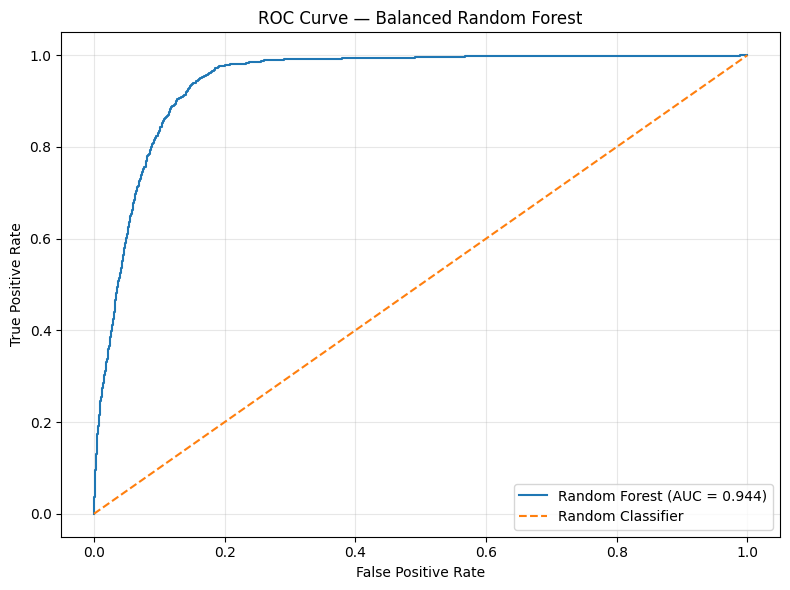

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

# ROC curve for balanced Random Forest
fpr, tpr, _ = roc_curve(y_test, rf_balanced_prob)

# Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(
    y_test,
    rf_balanced_prob
)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_balanced_prob):.3f})"
)
plt.plot([0, 1], [0, 1], "--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Balanced Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

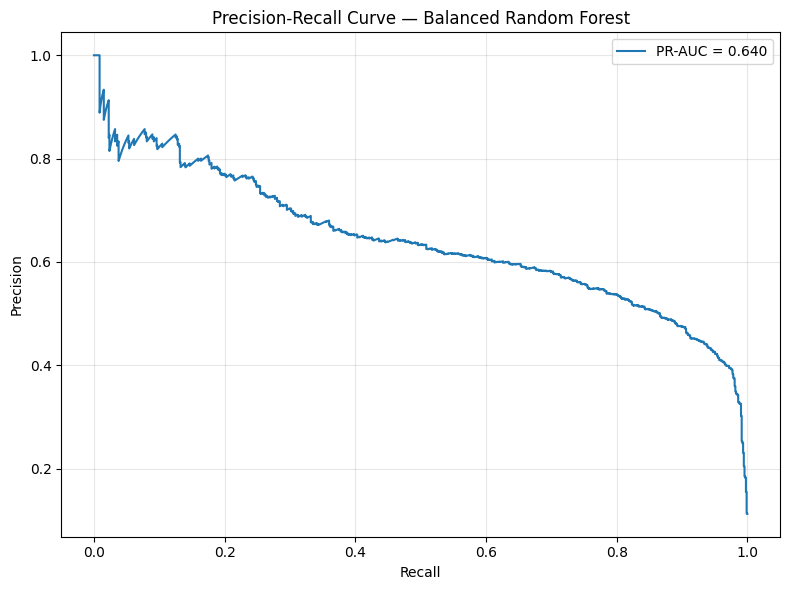

In [25]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall_vals,
    precision_vals,
    label=f"PR-AUC = {average_precision_score(y_test, rf_balanced_prob):.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Balanced Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The balanced Random Forest achieved a ROC-AUC of 0.944, indicating strong discrimination between potential subscribers and non-subscribers.

The Precision-Recall curve achieved a PR-AUC of 0.640. Since the target class is highly imbalanced, PR-AUC provides a more informative assessment of minority-class performance than accuracy alone.

The curves demonstrate that the model maintains a strong true-positive rate across a range of classification thresholds, while the Precision-Recall curve highlights the trade-off between identifying more subscribers and maintaining prediction precision.

## 20. Final Confusion Matrix

The confusion matrix evaluates the final balanced Random Forest using the business-optimized threshold of 0.25.

It shows the numbers of true negatives, false positives, false negatives, and true positives, allowing the model's practical business impact to be assessed.

Confusion Matrix:
[[5375 1933]
 [   9  919]]

Final Model Results
------------------------------
True Negatives: 5375
False Positives: 1933
False Negatives: 9
True Positives: 919

Business Cost:
False Positive Cost: $9,665
False Negative Cost: $4,500
Total Business Cost: $14,165


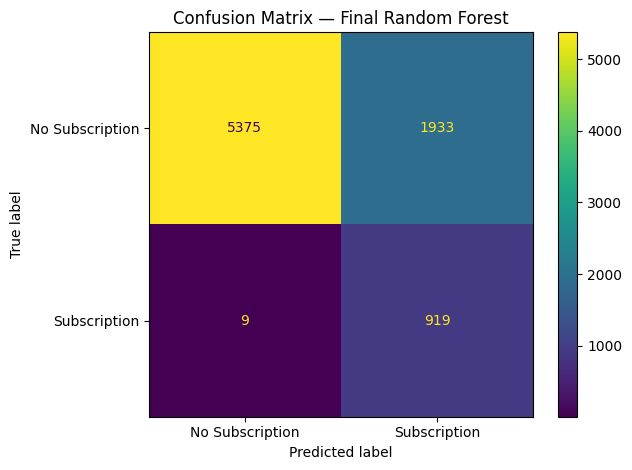

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Final predictions using optimized threshold
final_threshold = 0.25

final_pred = (rf_balanced_prob >= final_threshold).astype(int)

cm = confusion_matrix(y_test, final_pred)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nFinal Model Results")
print("-" * 30)
print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

print("\nBusiness Cost:")
print(f"False Positive Cost: ${fp * 5:,}")
print(f"False Negative Cost: ${fn * 500:,}")
print(f"Total Business Cost: ${(fp * 5) + (fn * 500):,}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Subscription", "Subscription"]
)

disp.plot()
plt.title("Confusion Matrix — Final Random Forest")
plt.tight_layout()
plt.show()

## 21. Final Model Evaluation

The balanced Random Forest was selected as the final model because it demonstrated strong discrimination and minority-class performance.

A business-oriented threshold of 0.25 was selected by minimizing the estimated cost of false-positive and false-negative predictions.

The final evaluation reports standard classification metrics together with the business cost associated with the selected threshold.

In [27]:
final_accuracy = accuracy_score(y_test, final_pred)
final_precision = precision_score(y_test, final_pred, zero_division=0)
final_recall = recall_score(y_test, final_pred, zero_division=0)
final_f1 = f1_score(y_test, final_pred, zero_division=0)

final_roc_auc = roc_auc_score(
    y_test,
    rf_balanced_prob
)

final_pr_auc = average_precision_score(
    y_test,
    rf_balanced_prob
)

final_business_cost = (fp * 5) + (fn * 500)

print("FINAL MODEL — BALANCED RANDOM FOREST")
print("=" * 45)
print("Threshold:", final_threshold)
print("Accuracy:", round(final_accuracy, 4))
print("Precision:", round(final_precision, 4))
print("Recall:", round(final_recall, 4))
print("F1 Score:", round(final_f1, 4))
print("ROC-AUC:", round(final_roc_auc, 4))
print("PR-AUC:", round(final_pr_auc, 4))
print("Business Cost: $", f"{final_business_cost:,}")

FINAL MODEL — BALANCED RANDOM FOREST
Threshold: 0.25
Accuracy: 0.7642
Precision: 0.3222
Recall: 0.9903
F1 Score: 0.4862
ROC-AUC: 0.9444
PR-AUC: 0.6399
Business Cost: $ 14,165


## 22. Final Model Comparison

The classification models were evaluated under three settings: standard training, class-weight balancing, and SMOTE-based balancing.

The comparison considers both statistical performance and the business objective. Since missing a potential subscriber has a much higher cost than making an unnecessary call, recall and business cost are given particular importance.

In [28]:
# Combine all model results

all_results = pd.concat(
    [
        results,
        balanced_results_df,
        smote_results_df
    ],
    ignore_index=True
)

display(
    all_results.round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Baseline,0.8873,0.0000,0.0000,0.0000,0.5000,0.1127
1,Logistic Regression,0.9095,0.6522,0.4224,0.5128,0.9390,0.6014
2,Decision Tree,0.9143,0.6500,0.5183,0.5767,0.9320,0.6094
3,Random Forest,0.9095,0.7427,0.3017,0.4291,0.9422,0.6527
4,SVM,0.9119,0.6683,0.4321,0.5249,0.9163,0.6292
5,KNN,0.9014,0.5858,0.4267,0.4938,0.8741,0.4920
6,Logistic Regression (Balanced),0.8643,0.4494,0.9084,0.6013,0.9403,0.5921
7,Decision Tree (Balanced),0.8384,0.4062,0.9407,0.5674,0.9355,0.6208
8,Random Forest (Balanced),0.8627,0.4473,0.9278,0.6036,0.9444,0.6399
9,Logistic Regression (SMOTE),0.8679,0.4565,0.9041,0.6067,0.9396,0.5893


## 23. Business Impact

The baseline classifier predicts every customer as a non-subscriber because of the strong class imbalance.

As a result, all actual subscribers are treated as false negatives. Since each missed subscriber represents an estimated $500 loss, the baseline produces a very high business cost.

The optimized Random Forest uses a threshold of 0.25 to prioritize identifying potential subscribers while minimizing the combined cost of unnecessary calls and missed subscribers.

In [29]:
# Baseline business cost
baseline_fn = int(y_test.sum())
baseline_fp = 0

baseline_business_cost = (
    baseline_fp * 5 +
    baseline_fn * 500
)

print("Business Impact Comparison")
print("=" * 35)

print(f"Baseline Business Cost: ${baseline_business_cost:,}")
print(f"Optimized Model Cost:   ${final_business_cost:,}")

cost_saving = baseline_business_cost - final_business_cost

print(f"Estimated Cost Saving:   ${cost_saving:,}")
print(
    f"Cost Reduction: "
    f"{(cost_saving / baseline_business_cost) * 100:.2f}%"
)

Business Impact Comparison
Baseline Business Cost: $464,000
Optimized Model Cost:   $14,165
Estimated Cost Saving:   $449,835
Cost Reduction: 96.95%


## 24. Business Conclusion

The analysis shows that class imbalance has a major effect on classification performance. The baseline model achieved 88.73% accuracy but failed to identify any subscribers, demonstrating why accuracy alone is insufficient for this problem.

Among the evaluated approaches, the balanced Random Forest provided strong discrimination with a ROC-AUC of 0.9444 and PR-AUC of 0.6399.

Business-aware threshold optimization selected a threshold of 0.25. At this threshold, the model achieved approximately 99.03% recall and identified 919 of 928 actual subscribers, while producing an estimated business cost of $14,165.

The optimized approach substantially reduces the estimated cost compared with the baseline, demonstrating the importance of class imbalance handling and threshold selection in cost-sensitive classification.

## 25. Limitations

- The business costs of $5 per unnecessary call and $500 per missed subscriber are assumed values from the problem scenario.
- The threshold search evaluated discrete values from 0.05 to 0.95 rather than every possible threshold.
- Model performance may vary on future campaigns or different customer populations.
- The analysis does not account for operational constraints such as a limited daily calling capacity.
- SMOTE and class weighting improve minority-class treatment but may introduce different precision-recall trade-offs.
- The final business cost is estimated from the test set and should be validated on future unseen campaign data before deployment.

## 26. Reproducibility

The solution uses fixed random seeds where applicable and separates preprocessing, model training, and evaluation.

The test set remains untouched during SMOTE-based training to prevent data leakage. All preprocessing transformations are performed through pipelines so that transformations learned from the training data are applied consistently to the test data.

The project is organized into modular components and can be reproduced using the dependencies specified in `requirements.txt`.